#### Imports

In [140]:
import importlib
import time
import copy
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import heapq
import pickle
import random
import re

from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel, Sum, Product
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, WhiteKernel, ConstantKernel as C, DotProduct
from sklearn.gaussian_process import GaussianProcessRegressor

import globals
import utils

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf, threshold=np.inf)

pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)

seed = 42
random.seed(seed)
np.random.seed(seed)

In [141]:
importlib.reload(globals)
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Masters_Thesis\\utils.py'>

In [142]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


In [143]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))

X_tr, X_val, X_test, Y_tr, Y_val, Y_test = utils.train_val_test_split(X, Y_resh, wavelengths, verbose=True)

X shape: (500, 9)
Y shape: (500, 6, 4205)
wavelengths shape: (4205,)

X_tr shape: (400, 9)
X_val shape: (50, 9)
X_test shape: (50, 9)

Y_tr shape: (400, 6, 4205)
Y_val shape: (50, 6, 4205)
Y_test shape: (50, 6, 4205)


#### Gaussian Process Pipeline

<ol>
    <li><b>Dimensionality Reduction</b>: PCA is implemented to reduce the outputs.</li>
    <li><b>Scaling</b>: standard scaling and min-max scaling are available to scale inputs and outputs.</li>
    <li><b>Fit</b> of the Gaussian Processes.</li>
    <li><b>Validation</b> of the Gaussian Processes.</li>
    <li><b>External Testing</b> of the Gaussian Processes.</li>
</ol>

In [144]:
def fit_gp(x_tr_scaled, y_tr_reduced_scaled, gp_kernel):
    """
    Fit a Gaussian Process Regressor for each output function. Reduced and scaled data is used to speed up fitting and improve performance
    - inputs: training inputs, training outputs, GP kernel to use for fitting
    - outputs: list of fitted GaussianProcessRegressor models for each output function and the time taken to fit all GPs
    """

    print("---------- Fitting Gaussian Process Regressor for each output function... ----------")

    gpr_list = []
    start_time_fit = time.time()
    for i in range(globals.N_FUNCTIONS):
        # more than 0 restarts causes a huge increase in fitting time without significant improvement in performance
        gpr = GaussianProcessRegressor(kernel=copy.deepcopy(gp_kernel), n_restarts_optimizer=0, random_state=42)
        gpr.fit(x_tr_scaled, y_tr_reduced_scaled[:, i, :])
        print("Learned kernel:", gpr.kernel_)
        gpr_list.append(gpr)
    end_time_fit = time.time()
    print(f"Time taken to fit GPs: {end_time_fit - start_time_fit:.2f} seconds")

    print("---------- Gaussian Process fitting completed. ----------\n")

    return gpr_list, end_time_fit - start_time_fit

In [145]:
def validate_gp(gpr_list, x_val_scaled, y_val, wavelengths, y_scalers, pca_list):
    """
    Validate the fitted Gaussian Process models on the validation set
    - inputs: list of fitted GaussianProcessRegressor models, validation inputs, validation outputs, wavelengths, list of scalers used for each output function, list of PCA objects for each output function
    - outputs: numpy array of predicted outputs on the validation set in the original space (n_samples, 6, 4205)
    """

    print("---------- Validating Gaussian Process models on the validation set... ----------")

    y_val_pred = np.zeros_like(y_val)  # (n_samples, 6, 4205)
    for i in range(globals.N_FUNCTIONS):
        y_pred_red_scaled = gpr_list[i].predict(x_val_scaled) # predictions in reduced and scaled space
        y_pred_red = y_scalers[i].inverse_transform(y_pred_red_scaled)  # inverse scaling
        y_pred = pca_list[i].inverse_transform(y_pred_red)  # inverse PCA
        y_val_pred[:, i, :] = y_pred

    print("y_val_pred shape:", y_val_pred.shape)

    # MRE calculation
    mre = utils.mre_score(y_val, y_val_pred, wavelengths)
    mae = utils.mae_score(y_val, y_val_pred, wavelengths)
    print(f"----- Validation MRE: {mre} -----")
    print(f"----- Validation MAE: {mae} -----")

    print("---------- Validation completed. ----------\n")

    return mre, mae

In [146]:
def core_kernel_names(kernel):
    """
    Recursively extract the names of the core kernels from a composite kernel.
    - inputs: kernel (sklearn.gaussian_process.kernels.Kernel)
    - outputs: list of core kernel names (list of strings)
    """

    # ignore noise + scaling wrappers
    if isinstance(kernel, WhiteKernel):
        return []

    if isinstance(kernel, C):
        return []

    if isinstance(kernel, Sum):
        return core_kernel_names(kernel.k1) + core_kernel_names(kernel.k2)

    if isinstance(kernel, Product):
        return core_kernel_names(kernel.k1) + core_kernel_names(kernel.k2)
    
    return [kernel.__class__.__name__]

def core_kernel_label(kernel):
    """
    Generate a label for the core kernel by joining the names of the core kernels with a '+' sign.
    - inputs: kernel (sklearn.gaussian_process.kernels.Kernel)
    - outputs: string label for the core kernel (string)
    """
    names = core_kernel_names(kernel)
    return "+".join(names)

Define kernels to try in the Gaussian Process fit.

In [147]:
n_feat = globals.N_INPUTS

kern_rbf = (
        C(1.0, (1e-3, 1e3)) *
        RBF(length_scale=np.ones(n_feat), length_scale_bounds=(1e-3, 1e3))
        + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e1))
    )

kern_matern = (
    C(1.0, (1e-3, 1e3))
    * Matern(
        length_scale=np.ones(n_feat),
        length_scale_bounds=(1e-3, 1e3),
        nu=2.5
    )
    + WhiteKernel(1e-2, (1e-5, 1e1))
)

kern_rq = (
    C(1.0, (1e-3, 1e3))
    * RationalQuadratic(
        length_scale=1.0,
        alpha=1.0,
        length_scale_bounds=(1e-3, 1e3),
        alpha_bounds=(1e-3, 1e3)
    )
    + WhiteKernel(1e-2, (1e-5, 1e1))
)

kern_rbf_rq = (
    C(1.0, (1e-3, 1e3))
    * (
        RBF(
            length_scale=np.ones(n_feat),
            length_scale_bounds=(1e-3, 1e3)
        )
        + RationalQuadratic(
            length_scale=1.0,
            alpha=1.0
        )
    )
    + WhiteKernel(1e-2, (1e-5, 1e1))
)

kern_dot_rbf = (
    C(1.0, (1e-3, 1e3))
    * (
        DotProduct()
        + RBF(
            length_scale=np.ones(n_feat),
            length_scale_bounds=(1e-3, 1e3)
        )
    )
    + WhiteKernel(1e-2, (1e-5, 1e1))
)

kern_linear = (
    C(1.0, (1e-3, 1e3))
    * DotProduct()
    + WhiteKernel(1e-2, (1e-5, 1e1))
)

kern_matern_rq = (
    C(1.0, (1e-3, 1e3))
    * (
        Matern(
            length_scale=np.ones(n_feat),
            nu=1.5
        )
        + RationalQuadratic()
    )
    + WhiteKernel(1e-2, (1e-5, 1e1))
)

Apply the whole pipeline.

In [ ]:
# param_grid = {
#     "pca_kernel": [None],
#     "gamma": [1e-2],
#     "alpha": [1e-1],
#     "degree": [3],
#     "scale_type": ["standard", "minmax"],
#     "gp_kernel": [kern_rbf, kern_matern, kern_rq, kern_rbf_rq, kern_dot_rbf, kern_linear, kern_matern_rq]
# }
param_grid = {
    "scale_type": ["minmax"],
    "gp_kernel": [kern_matern, kern_linear]
}

gp_results = []

for scale_type in param_grid["scale_type"]:
    for gp_kernel in param_grid["gp_kernel"]:
        gp_kernel_full_name = str(gp_kernel).replace(" ", "")
        print(f"========== Running GP pipeline with scale_type={scale_type} and gp_kernel={gp_kernel_full_name}... ==========")

        # dimensionality reduction
        pca_list, Y_tr_pca, _ = utils.apply_pca(Y_tr, Y_val, n_components=10)

        # scaling
        x_scaler, X_tr_scaled, X_val_scaled = utils.scale_input_data(X_tr, X_val, scale_type=scale_type)
        y_scalers, Y_tr_reduced_scaled, _ = utils.scale_output_data(Y_tr_pca, _, scale_type=scale_type)

        # fit Gaussian Process
        gpr_list, gp_fit_time = fit_gp(X_tr_scaled, Y_tr_reduced_scaled, gp_kernel)

        # validate Gaussian Process
        mre, mae = validate_gp(gpr_list, X_val_scaled, Y_val, wavelengths, y_scalers, pca_list)

        # save models and write parameters and metrics to csv file
        model_name = core_kernel_label(gp_kernel)
        dataset_size = int(re.search(r'\d+', Path(globals.CURRENT_TRAIN_FILE).stem).group())
        exp_id = f"{model_name}_{scale_type}_{dataset_size}"

        entry = {
            "experiment_id": exp_id,
            "gp_kernel_full_name": gp_kernel_full_name,
            "model": model_name,
            "scale_type": scale_type,
            "dataset_size": dataset_size,
            "fit_time": gp_fit_time,
            "best_val_mre": mre,
            "best_val_mae": mae,
            "gpr_list": gpr_list,
            "pca_list": pca_list,
            "x_scaler": x_scaler,
            "y_scalers": y_scalers
        }
        gp_results.append(entry)
        
        results_df = pd.DataFrame([entry]).drop(columns=["gpr_list", "pca_list", "x_scaler", "y_scalers"])
        results_df.to_csv("./gp_saves/gp_results.csv", mode="a", header=not Path("./gp_saves/gp_results.csv").exists(), index=False)
        print("================================================== GP pipeline completed. ==================================================\n")

# save top results in pickle
with open("./gp_saves/model_saves/gp_results.pkl", "wb") as f:
    pickle.dump(gp_results, f)

========== Running GP pipeline with scale_type=minmax and gp_kernel=1**2*Matern(length_scale=[1,1,1,1,1,1,1,1,1],nu=2.5)+WhiteKernel(noise_level=0.01)... ==========
---------- Applying PCA with n_components=10 to each function separately... ----------
  Regular PCA used, displaying results:
  Function 1: Explained variance = 1.0000
  Number of components retained: 10

  Function 2: Explained variance = 1.0000
  Number of components retained: 10

  Function 3: Explained variance = 1.0000
  Number of components retained: 10

  Function 4: Explained variance = 0.9999
  Number of components retained: 10

  Function 5: Explained variance = 1.0000
  Number of components retained: 10

  Function 6: Explained variance = 1.0000
  Number of components retained: 10

  Total explained variance = 5.9999
---------- PCA application completed. ----------

---------- Scaling input data using minmax scaling... ----------
---------- Input data scaling completed. ----------

---------- Scaling output data

c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel: 3.74**2 * Matern(length_scale=[19.2, 4.75, 4.36, 9.04, 5.07, 31.8, 4.25, 15.2, 6.74], nu=2.5) + WhiteKernel(noise_level=1e-05)


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  w

Learned kernel: 2.71**2 * Matern(length_scale=[33.8, 2.74, 5.26, 1e+03, 3.42, 1e+03, 2.18, 8.68, 2.81], nu=2.5) + WhiteKernel(noise_level=1e-05)


...

Learned kernel: 8.04**2 * Matern(length_scale=[51.6, 3.9, 6.83, 40.1, 7.31, 51.9, 6.59, 294, 1e+03], nu=2.5) + WhiteKernel(noise_level=1e-05)
Learned kernel: 2.39**2 * Matern(length_scale=[180, 3.07, 2.67, 10.1, 3.69, 23.3, 4.19, 901, 6.59], nu=2.5) + WhiteKernel(noise_level=3.05e-05)


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 6 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better valu

Learned kernel: 15.1**2 * Matern(length_scale=[170, 3.11, 9.9, 1e+03, 7.08, 1e+03, 1e+03, 23.7, 1e+03], nu=2.5) + WhiteKernel(noise_level=1e-05)


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel: 5.84**2 * Matern(length_scale=[51.1, 4.12, 5.84, 41.6, 4.98, 43.3, 4.91, 25.7, 5.44], nu=2.5) + WhiteKernel(noise_level=1e-05)
Time taken to fit GPs: 11.48 seconds
---------- Gaussian Process fitting completed. ----------

---------- Validating Gaussian Process models on the validation set... ----------
y_val_pred shape: (50, 6, 4205)
----- Validation MRE: 0.0024477317929267883 -----
----- Validation MAE: 0.20448225736618042 -----
---------- Validation completed. ----------

================================================== GP pipeline completed. ==================================================

========== Running GP pipeline with scale_type=minmax and gp_kernel=1**2*DotProduct(sigma_0=1)+WhiteKernel(noise_level=0.01)... ==========
---------- Applying PCA with n_components=10 to each function separately... ----------
  Regular PCA used, displaying results:
  Function 1: Explained variance = 1.0000
  Number of components retained: 10

  Function 2: Explained variance 

#### Analysis of Validation Results

Average Fit Time by Dataset Size
 dataset_size  avg_fit_time
          500      6.831005

Average Best Val MRE by Dataset Size & Model
 dataset_size      model  avg_best_val_mre
          500 DotProduct          0.050439
          500     Matern          0.002448

Average Best Val MAE by Dataset Size & Model
 dataset_size      model  avg_best_val_mae
          500 DotProduct          5.886972
          500     Matern          0.204482

Average Best Val MRE & MAE by Model (Across Dataset Sizes)
     model  avg_best_val_mre  avg_best_val_mae
DotProduct          0.050439          5.886972
    Matern          0.002448          0.204482

Average Best Val MRE & MAE by Dataset Size (Across Models)
 dataset_size  avg_best_val_mre  avg_best_val_mae
          500          0.026443          3.045727


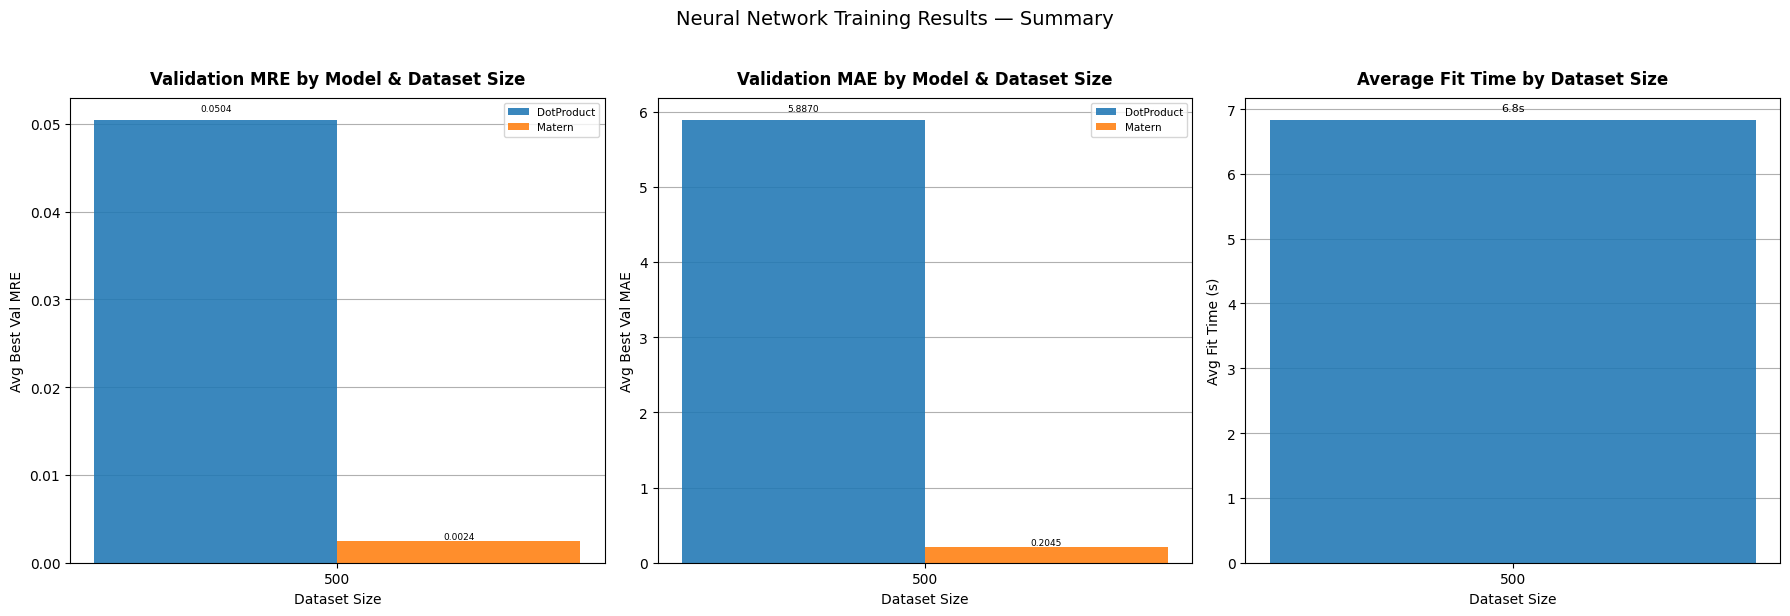


Figure saved to gp_saves/gp_results_analysis.png


In [148]:
# load and analyze csv results
results_df = pd.read_csv("./gp_saves/gp_results.csv")
utils.show_fit_val_summary(results_df, save_path="gp_saves/gp_results_analysis.png")

In [149]:
utils.show_top_results(results_df, top_n=5)


Top 5 Results by Best Validation MRE:
        experiment_id                                                                gp_kernel_full_name      model scale_type  dataset_size  fit_time  best_val_mre  best_val_mae
    Matern_minmax_500 1**2*Matern(length_scale=[1,1,1,1,1,1,1,1,1],nu=2.5)+WhiteKernel(noise_level=0.01)     Matern     minmax           500 11.475001      0.002448      0.204482
DotProduct_minmax_500                           1**2*DotProduct(sigma_0=1)+WhiteKernel(noise_level=0.01) DotProduct     minmax           500  2.187009      0.050439      5.886972


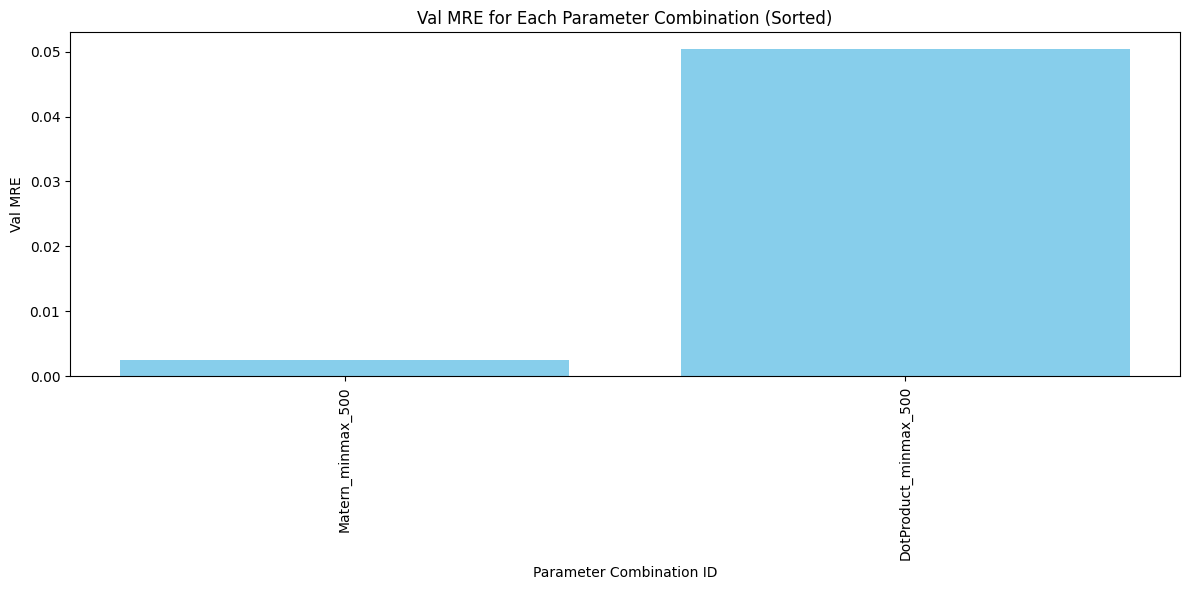


Bar plot saved to gp_saves/gp_results_barplot.png


In [150]:
utils.show_barplot_results(results_df, save_path="gp_saves/gp_results_barplot.png")

#### External Testing

For both MRE and MAE:
<ul>
    <li>Global average metric.</li>
    <li>Metric for each function.</li>
    <li>Metric for each wavelength.</li>
    <li>Metric for each function and for each wavelength.</li>
</ul>

In [151]:
gp_results = pickle.load(open("./gp_saves/model_saves/gp_results.pkl", "rb"))

# order results by best validation MRE
gp_results_sorted = sorted(gp_results, key=lambda x: x["best_val_mre"])

idx = 0 # index of the model to use for test prediction (0 is the best one)
gpr_list = gp_results_sorted[idx]["gpr_list"]
pca_list = gp_results_sorted[idx]["pca_list"]
x_scaler = gp_results_sorted[idx]["x_scaler"]
y_scalers = gp_results_sorted[idx]["y_scalers"]

In [152]:
# predict on test set with chosen model
Y_test_pred = np.zeros_like(Y_test)  # (n_samples, 6, 4205)
Y_test_std = np.zeros_like(Y_test)  # (n_samples, 6, 4205)

X_test_scaled = x_scaler.transform(X_test) # scale test inputs with the same scaler used for training

for i in range(globals.N_FUNCTIONS):
    # 1. get latent predictions and uncertainty
    # y_pred_red_scaled: (n_samples, n_components)
    # y_std_red_scaled:  (n_samples, n_components)
    Y_pred_red_scaled, Y_std_red_scaled = gpr_list[i].predict(X_test_scaled, return_std=True)

    # 2. inverse Scaling
    Y_pred_red = y_scalers[i].inverse_transform(Y_pred_red_scaled)

    # scale the standard deviation based on the scaler type
    if str(y_scalers[i]) == "StandardScaler()":
        Y_std_red = Y_std_red_scaled * y_scalers[i].scale_
    else: # MinMaxScaler
        Y_std_red = Y_std_red_scaled * (y_scalers[i].data_max_ - y_scalers[i].data_min_)

    # 3. inverse PCA reconstruction
    Y_pred = pca_list[i].inverse_transform(Y_pred_red)

    # 4. propagate variance through PCA
    # W is the components matrix: (n_components, n_wavelengths)
    W = pca_list[i].components_
    
    # variance in original space: Var(Y) = W^T * Var(Z) * W 
    # since components are treated as independent, this simplifies:
    # Y_std_full[wavelength] = sqrt( sum( W[comp, wavelength]^2 * latent_var[comp] ) )
    latent_var = Y_std_red**2  # shape (n_samples, n_components)

    # matrix multiplication to get variance per wavelength: (n_samples, n_wavelengths)
    # (n_samples, n_components) @ (n_components, n_wavelengths)
    Y_var_full = latent_var @ (W**2)
    Y_std_full = np.sqrt(Y_var_full)

    # 5. store results
    Y_test_pred[:, i, :] = Y_pred
    Y_test_std[:, i, :] = Y_std_full

Testing MRE: 0.002302352
Path Radiance MRE: 0.0056
Direct Solar Irradiance MRE: 0.0011
Diffuse Solar Irradiance MRE: 0.0025
Spherical Albedo MRE: 0.0025
Direct Transmittance MRE: 0.0002
Diffuse Transmittance MRE: 0.0019


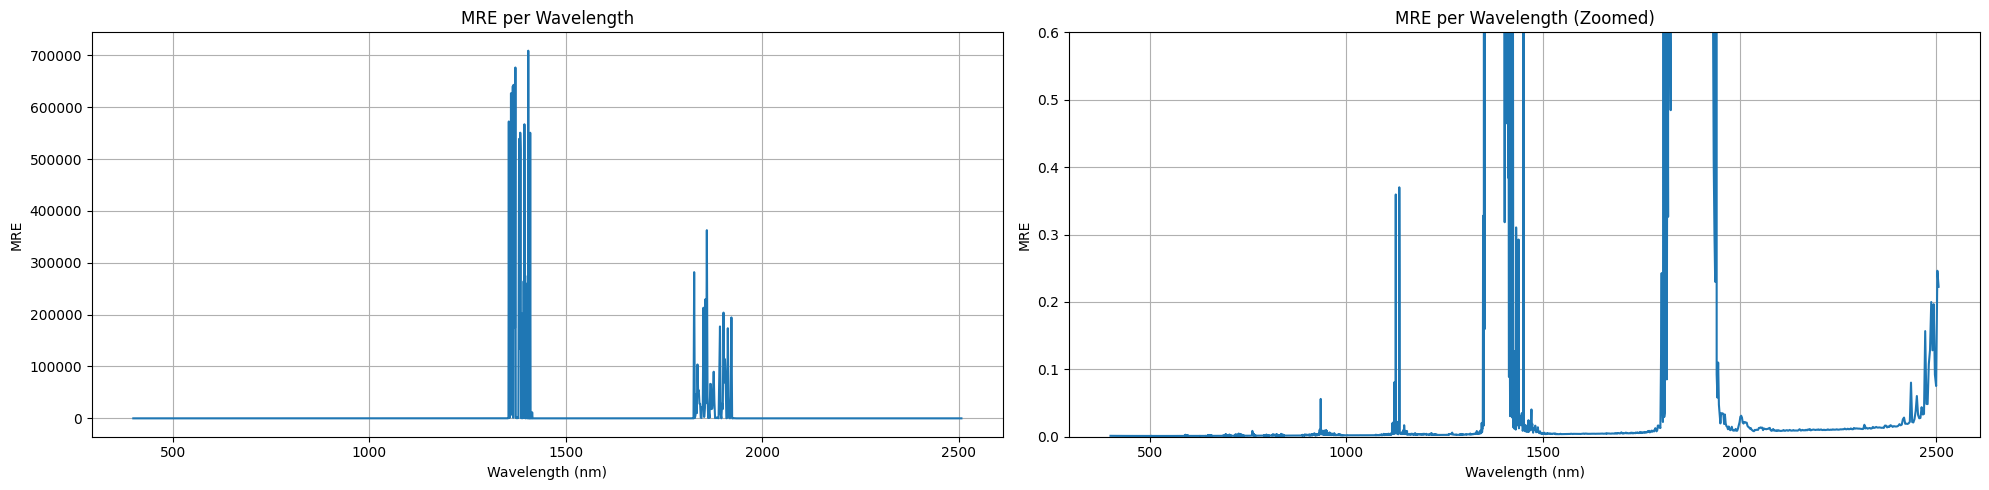

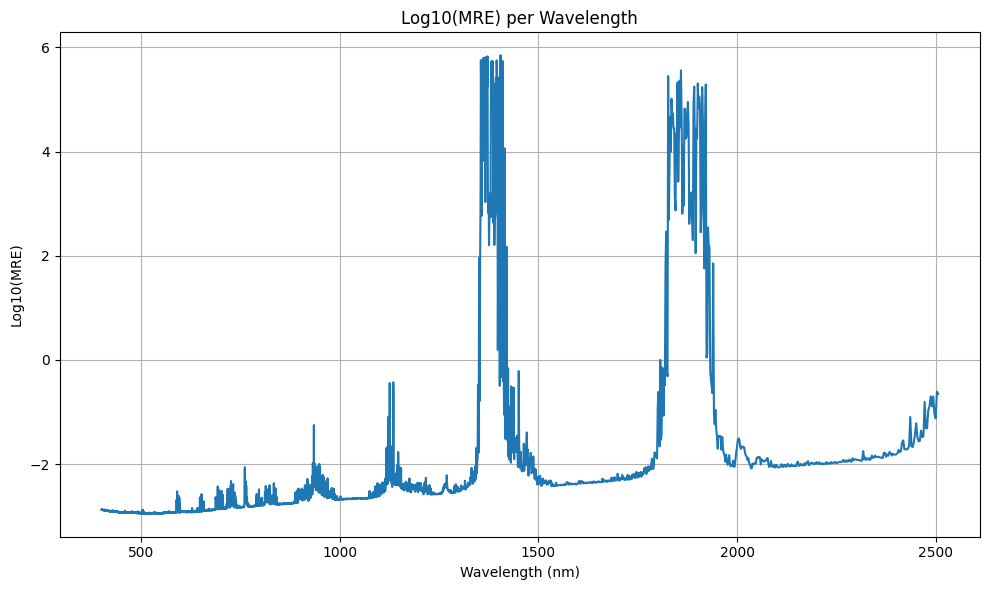

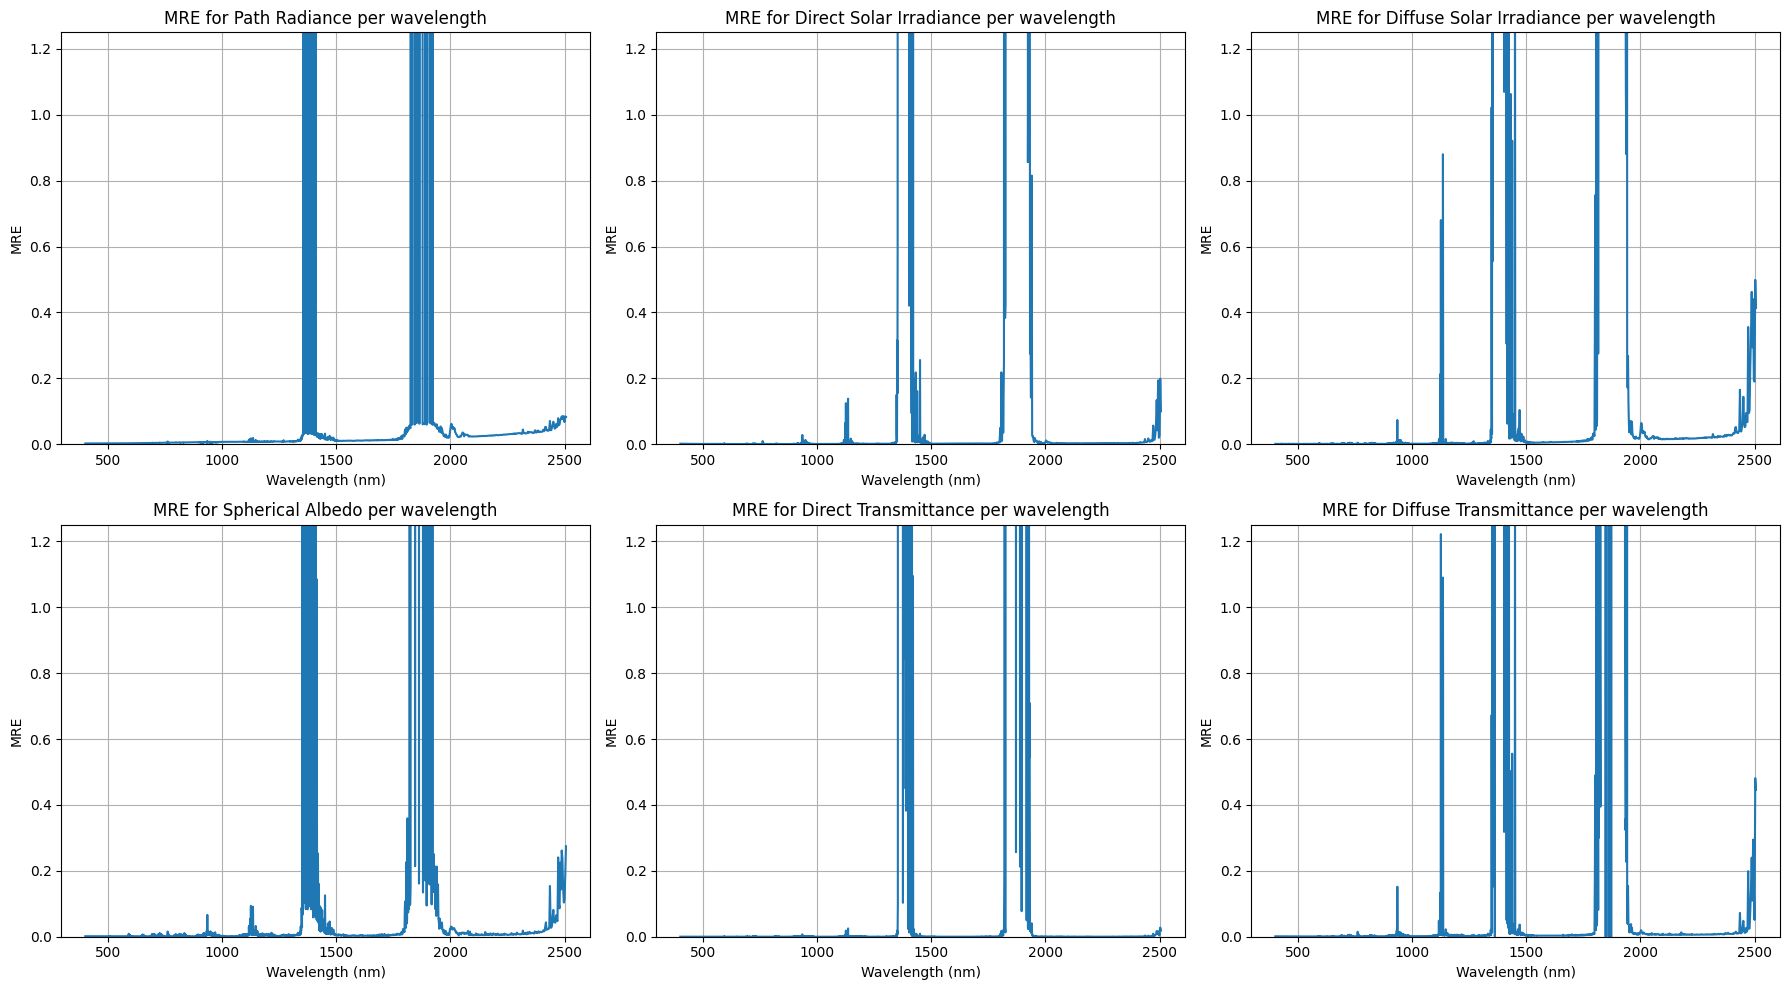

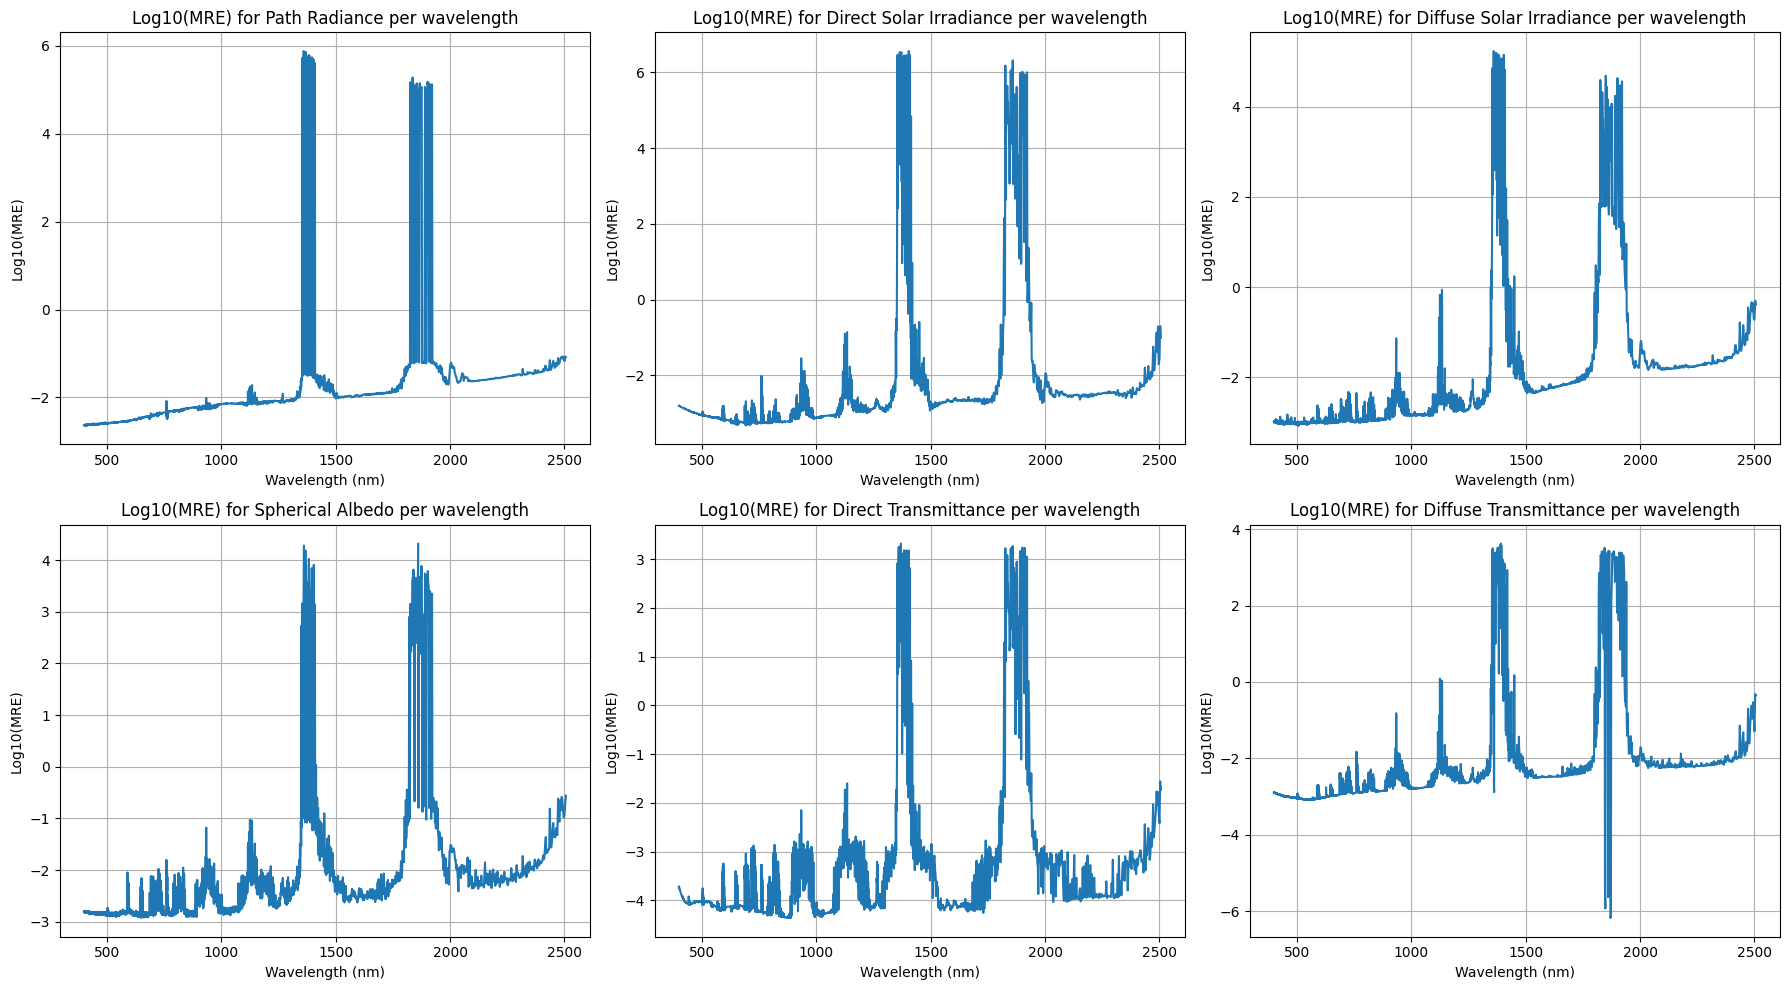

In [153]:
utils.show_test_results_mre(Y_test, Y_test_pred, wavelengths)

Testing MAE: 0.1686549
Path Radiance MAE: 0.0602
Direct Solar Irradiance MAE: 0.6688
Diffuse Solar Irradiance MAE: 0.2824
Spherical Albedo MAE: 0.0002
Direct Transmittance MAE: 0.0001
Diffuse Transmittance MAE: 0.0002


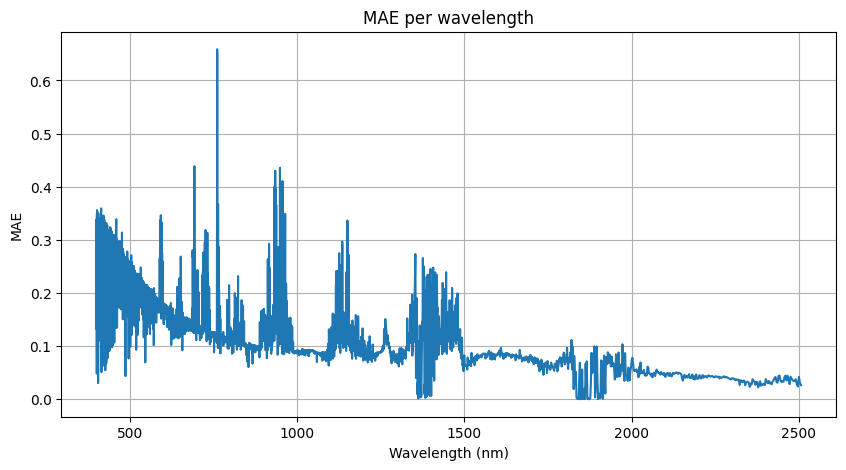

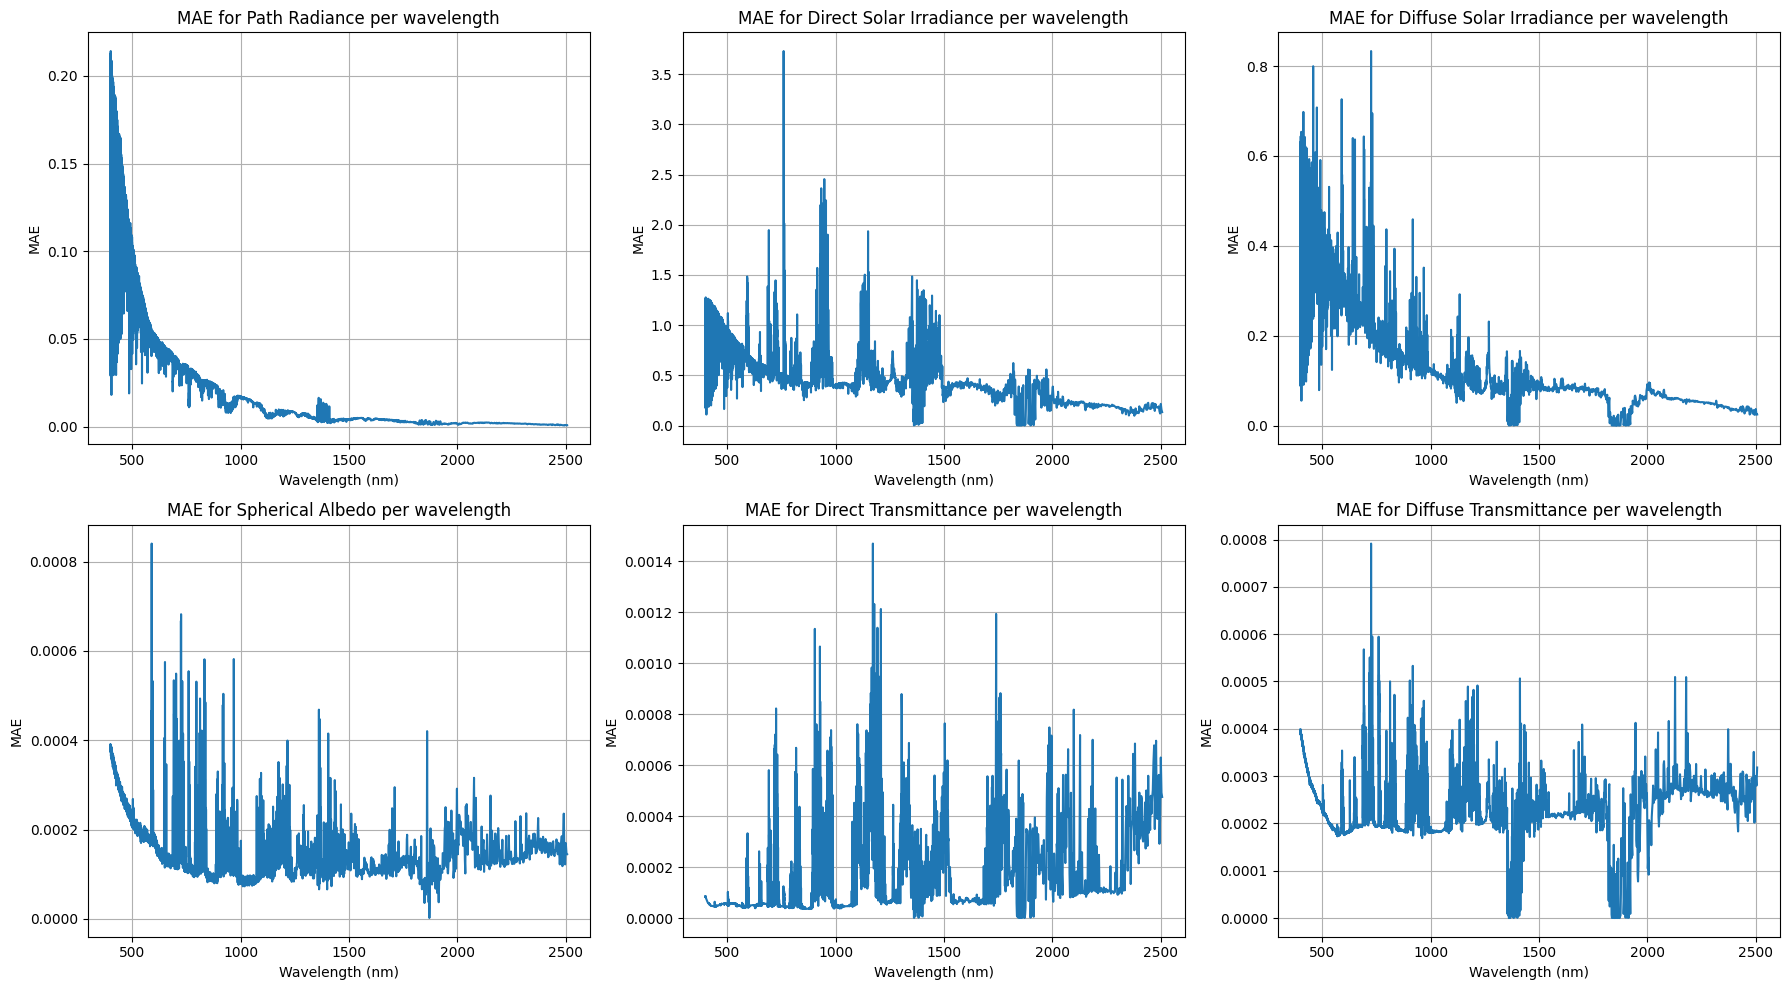

In [154]:
utils.show_test_results_mae(Y_test, Y_test_pred, wavelengths)

Global Coverage Probability (2σ): 97.84%
------------------------------
Path Radiance   Coverage: 97.72%
Direct Solar Irradiance Coverage: 98.09%
Diffuse Solar Irradiance Coverage: 96.50%
Spherical Albedo Coverage: 98.46%
Direct Transmittance Coverage: 98.23%
Diffuse Transmittance Coverage: 98.06%


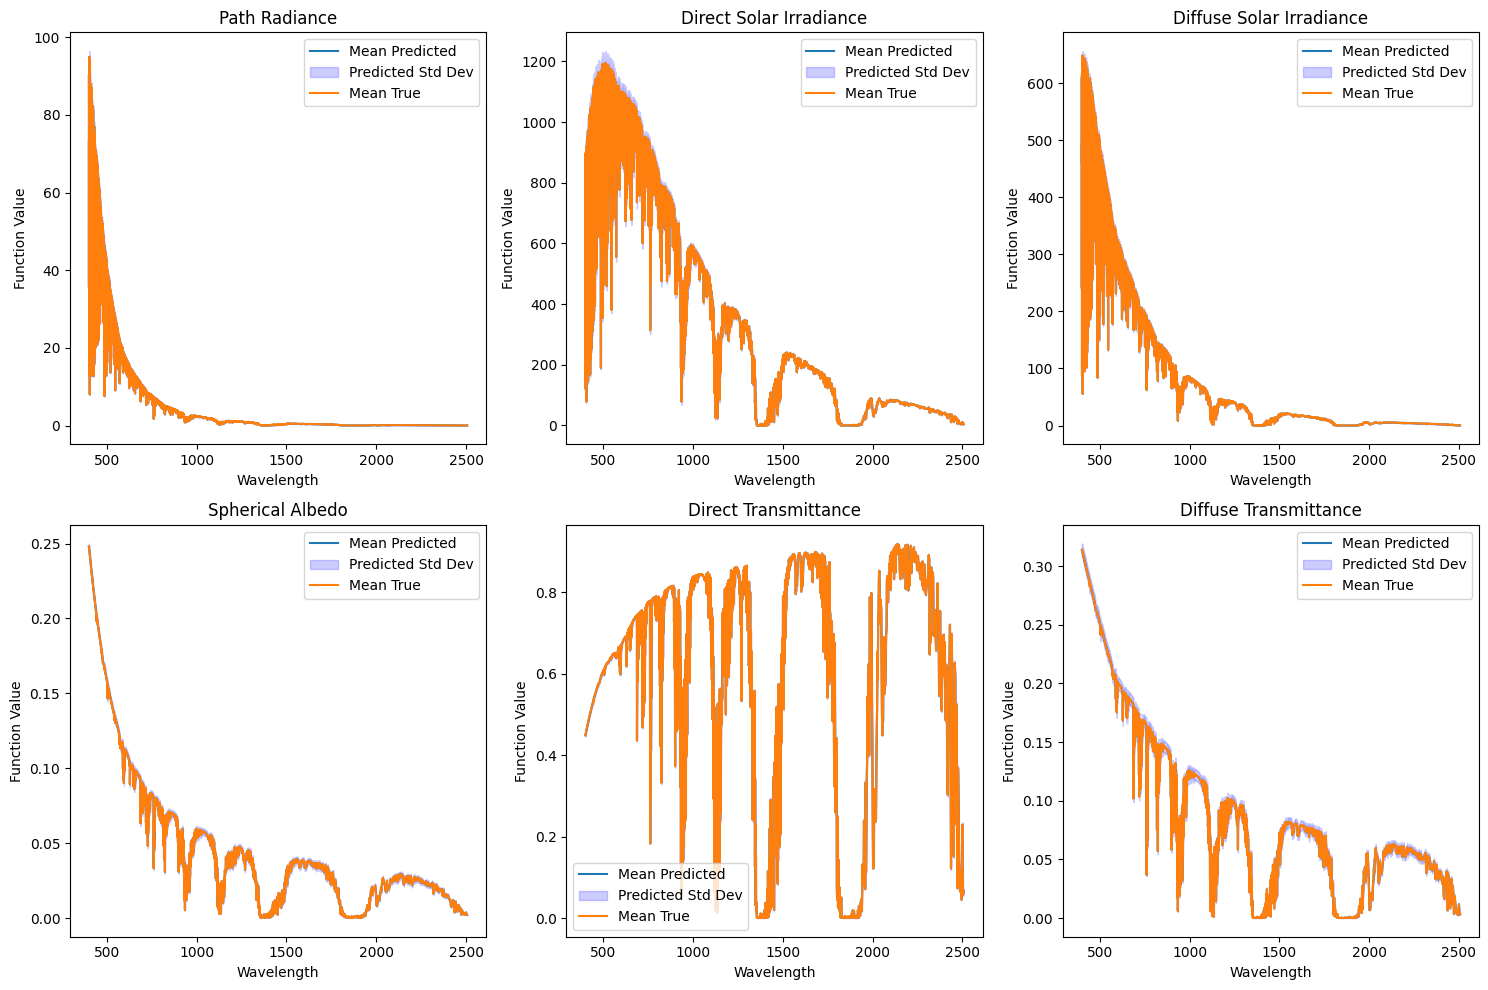

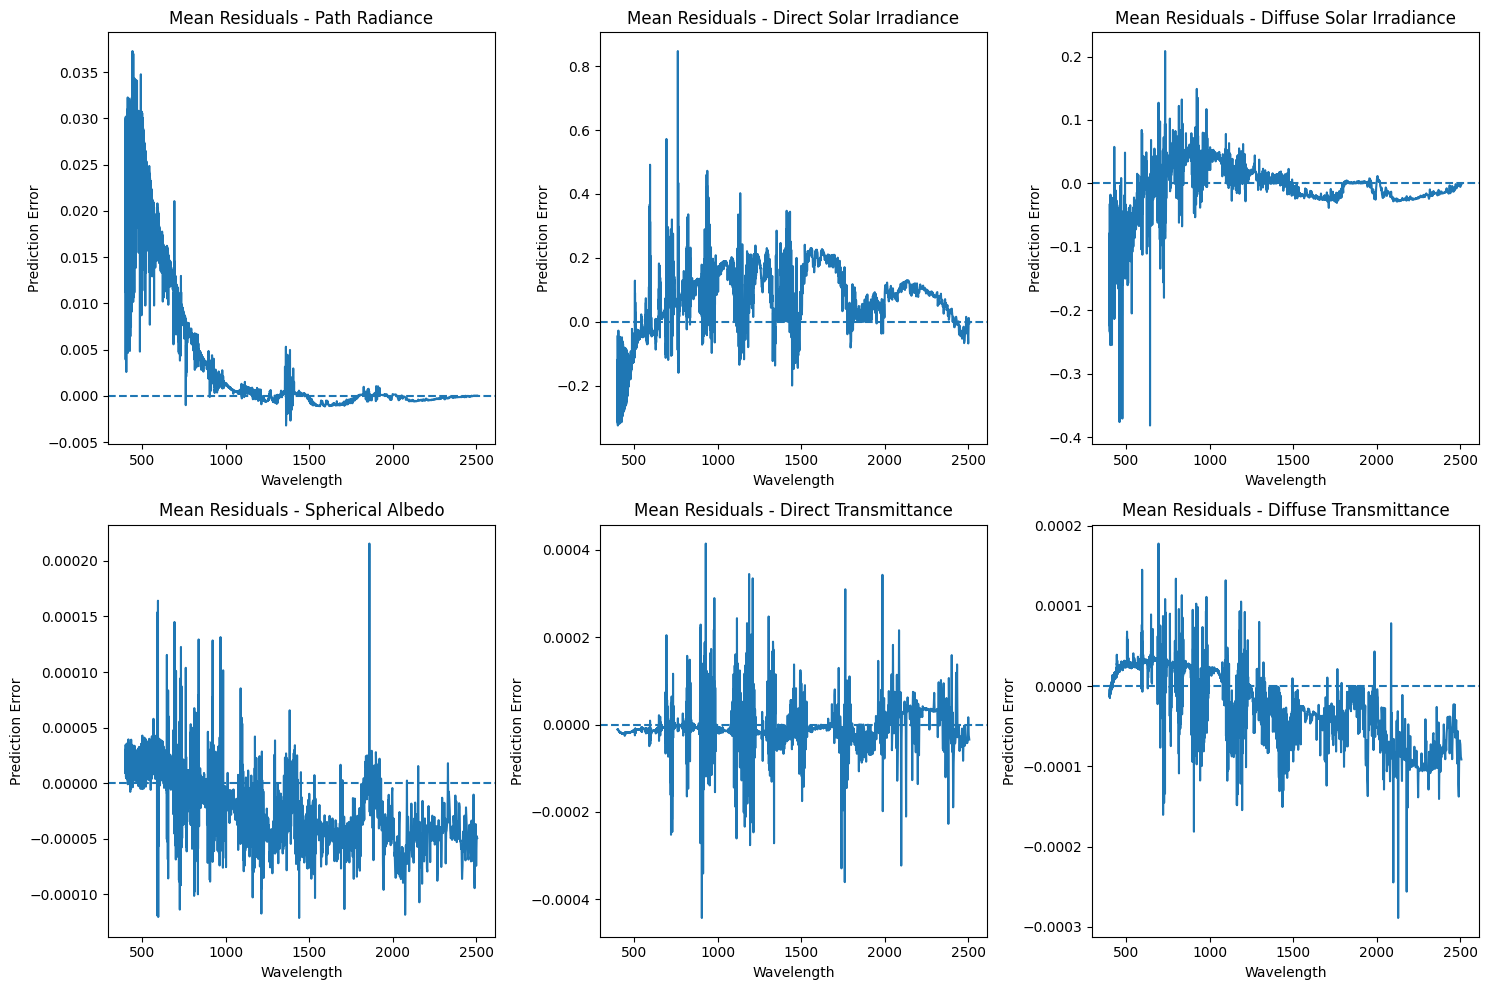

In [ ]:
# --- coverage probability ---
global_cov, func_cov = utils.calculate_coverage(Y_test, Y_test_pred, Y_test_std)
print(f"Global Coverage Probability ({2}σ): {global_cov:.2f}%")
print("-" * 30)
for i, name in enumerate(globals.function_names_plots):
    print(f"{name:15} Coverage: {func_cov[i]:.2f}%")


# --- compute mean true and predicted functions across all samples ---
Y_true_mean = np.mean(Y_test, axis=0)        # shape: (6, 4205)
Y_pred_mean = np.mean(Y_test_pred, axis=0)       # shape: (6, 4205)
Y_std_mean = np.mean(Y_test_std, axis=0)        # shape: (6, 4205)

# plot mean true vs predicted
plt.figure(figsize=(15, 10))

for i in range(globals.N_FUNCTIONS):  # iterate over functions
    plt.subplot(2, 3, i + 1)

    plt.plot(wavelengths, Y_pred_mean[i], label="Mean Predicted")
    # with Gaussian prior, 2 standard deviations should cover ~95% of the true function values
    plt.fill_between(wavelengths, Y_pred_mean[i] - 2 * Y_std_mean[i], Y_pred_mean[i] + 2 * Y_std_mean[i], color="blue", alpha=0.2, label="Predicted Std Dev")
    plt.plot(wavelengths, Y_true_mean[i], label="Mean True")

    plt.title(f"{globals.function_names_plots[i]}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Function Value (" + globals.function_units_plots[i] + ")")
    plt.legend()

plt.tight_layout()
plt.show()


# --- residuals for all samples ---
residuals = Y_test_pred - Y_test   # shape: (n_samples, 6, 4205)

# mean residual across samples
mean_residuals = np.mean(residuals, axis=0)  # shape: (6, 4205)

plt.figure(figsize=(15, 10))

for i in range(globals.N_FUNCTIONS):
    plt.subplot(2, 3, i + 1)

    plt.plot(wavelengths, mean_residuals[i])
    plt.axhline(0, linestyle="--")

    plt.title(f"Mean Residuals - {globals.function_names_plots[i]}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Prediction Error")

plt.tight_layout()
plt.show()

Load the test csv and apply the model to measure inference runtime.

In [155]:
X_test_csv = utils.load_test_csv(globals.CURRENT_TEST_FILE)
print(f"Test inputs from CSV shape: {X_test_csv.shape}")

# scale test inputs with the same scaler used for training
X_test_csv_scaled = x_scaler.transform(X_test_csv)

# predict on test CSV with chosen model
Y_test_csv_pred = np.zeros((X_test_csv.shape[0], globals.N_FUNCTIONS, Y_tr.shape[2]))  # (n_samples, 6, 4205)
Y_test_csv_std = np.zeros((X_test_csv.shape[0], globals.N_FUNCTIONS, Y_tr.shape[2]))  # (n_samples, 6, 4205)
start_time_test_csv = time.time()
for i in range(globals.N_FUNCTIONS):
    Y_pred_red_scaled, Y_std_red_scaled = gpr_list[i].predict(X_test_csv_scaled, return_std=True) # predictions in reduced and scaled space

    # inverse predictions
    Y_pred_red = y_scalers[i].inverse_transform(Y_pred_red_scaled)  # inverse scaling
    Y_pred = pca_list[i].inverse_transform(Y_pred_red)  # inverse PCA
    Y_test_csv_pred[:, i, :] = Y_pred

    # inverse std
    if str(y_scalers[i]) == "StandardScaler()":
        Y_std_red = Y_std_red_scaled * y_scalers[i].scale_
    else: # MinMaxScaler
        Y_std_red = Y_std_red_scaled * (y_scalers[i].data_max_ - y_scalers[i].data_min_)
    W = pca_list[i].components_ 
    latent_var = Y_std_red**2  # shape (n_samples, n_components)
    Y_var_full = latent_var @ (W**2) 
    Y_std_full = np.sqrt(Y_var_full)
    Y_test_csv_std[:, i, :] = Y_std_full

end_time_test_csv = time.time()
print(f"Time taken to predict on test CSV: {end_time_test_csv - start_time_test_csv:.2f} seconds")
print("Predictions on test CSV shape:", Y_test_csv_pred.shape)
print("Std on test CSV shape:", Y_test_csv_std.shape)

Test inputs from CSV shape: (10000, 9)
Time taken to predict on test CSV: 4.48 seconds
Predictions on test CSV shape: (10000, 6, 4205)
Std on test CSV shape: (10000, 6, 4205)


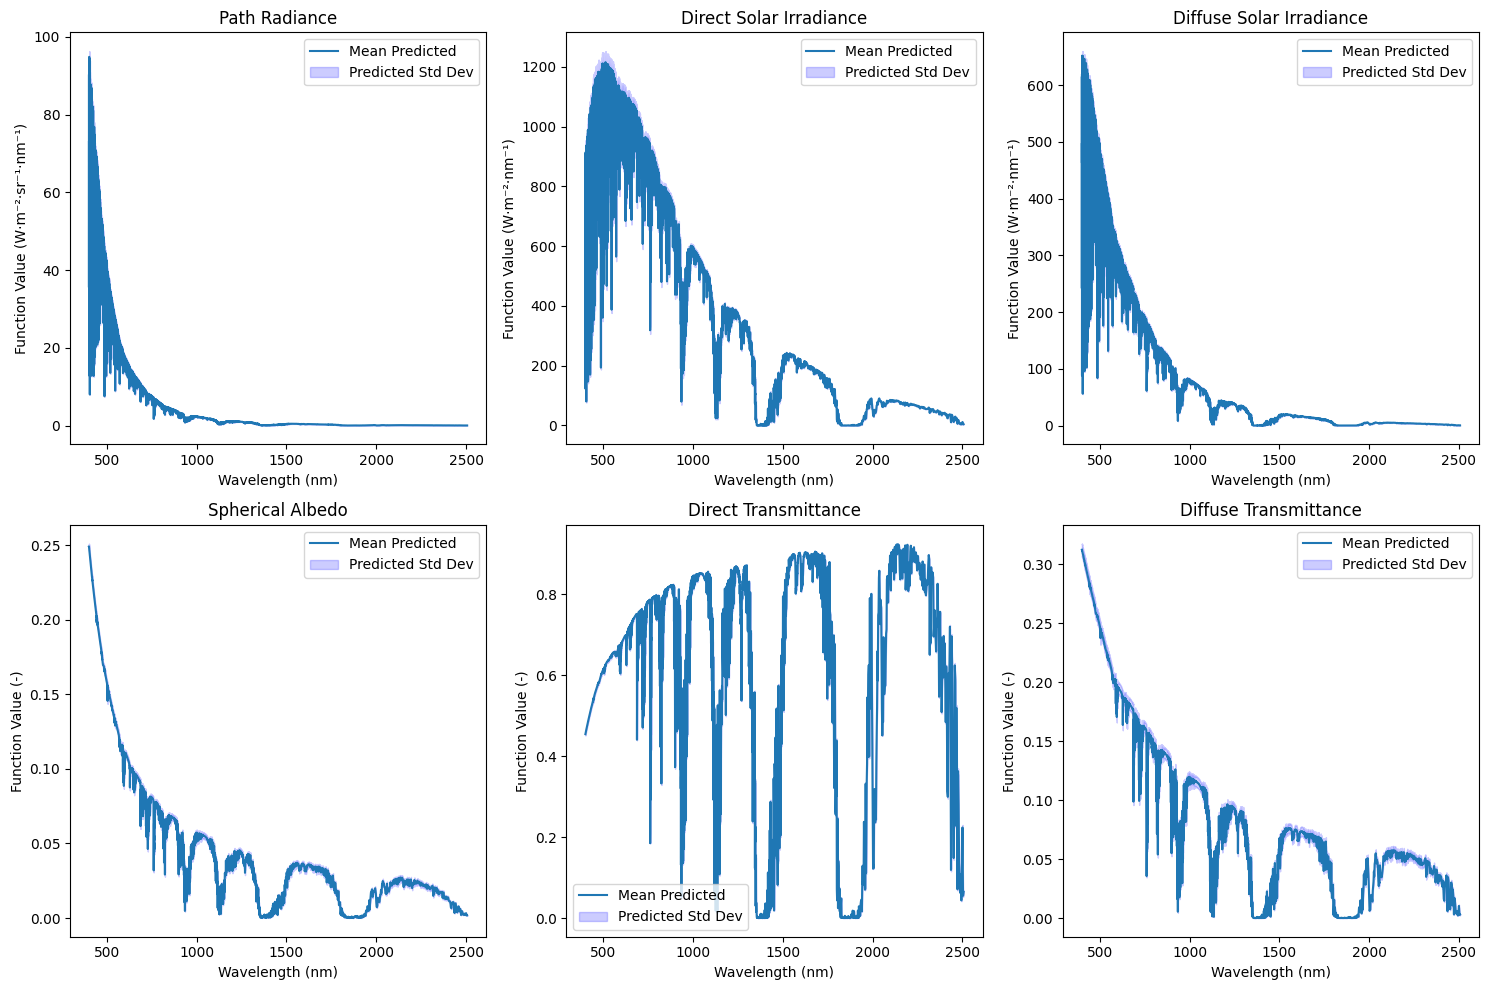

In [156]:
# compute mean predicted functions across all samples
Y_pred_mean = np.mean(Y_test_csv_pred, axis=0)
Y_std_mean = np.mean(Y_test_csv_std, axis=0)

plt.figure(figsize=(15, 10))

for i in range(globals.N_FUNCTIONS):
    plt.subplot(2, 3, i + 1)

    plt.plot(wavelengths, Y_pred_mean[i], label="Mean Predicted")
    plt.fill_between(wavelengths, Y_pred_mean[i] - 2 * Y_std_mean[i], Y_pred_mean[i] + 2 * Y_std_mean[i], color="blue", alpha=0.2, label="Predicted Std Dev")

    plt.title(f"{globals.function_names_plots[i]}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Function Value (" + globals.function_units_plots[i] + ")")
    plt.legend()

plt.tight_layout()
plt.show()